# Caching Schemes Experimentation

## Experiment Hyperparameters

In [316]:
CACHE_SIZE = 5
MAX_NODES = 100
MIN_NODES = 12
ITERS_PER_GRAPH = 30
ITERS_PER_SIZE = 30

## Experiment

In [317]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

def random_graph(n, p):
    G: nx.DiGraph = nx.gnp_random_graph(n, p, directed=True)
    # Sample node weights using a power-law distribution
    alpha = 2.5  # Power-law exponent
    weights = np.random.power(alpha, size=len(G.nodes()))  # Power-law distribution
    # weights = [random.random() for _ in range(len(G.nodes()))]
    # scramble the weights
    random.shuffle(weights)
    total_weight = sum(weights)
    normalized_weights = [weight / total_weight for weight in weights]
    for node, weight in zip(G.nodes(), normalized_weights):
        G.nodes[node]['weight'] = weight
    return G

## PageRank + LRU

In [318]:
import networkx as nx
import random
from tqdm import tqdm
from collections import defaultdict, OrderedDict

page_rank_lru_hit_rate = defaultdict(int) # hit_rate[i] = hit rate for graph size i

for n in tqdm(range(MIN_NODES, MAX_NODES+1)):  # Loop over graph sizes
    hit_rate = []
    
    for _ in range(ITERS_PER_SIZE):  # Generate random graphs for each size
        total_hits = 0
        total_misses = 0
        p = random.uniform(0, 1)  # Randomly select edge probability
        G = random_graph(n, p)
        frequency = defaultdict(int)
        page_rank = nx.pagerank(G)
        # Cache the top 10 nodes based on PageRank
        cached_nodes = set(sorted(page_rank, key=page_rank.get, reverse=True)[:CACHE_SIZE//2])
        lru_cache_size = CACHE_SIZE - len(cached_nodes)
        lru_cache = OrderedDict()
        init = set(random.choices(list(set(G.nodes()) - cached_nodes), k=lru_cache_size))
        for node in init:
            lru_cache[node] = None
        assert set(lru_cache.keys()) & cached_nodes == set()
        for _ in range(ITERS_PER_GRAPH):  # Randomly select nodes to test
            assert set(lru_cache.keys()) & cached_nodes == set()
            u = random.choices(list(G.nodes()), weights=[G.nodes[node]['weight'] for node in G.nodes()])[0]
            # Get dependencies of `u`
            dependencies = set(G[u]) | {u}

            # Update cache based on dependencies
            for dep in dependencies:
                if dep in cached_nodes: continue
                if dep in lru_cache:
                    # Move the accessed item to the end (mark as recently used)
                    lru_cache.move_to_end(dep)
                else:
                    # Add new item, evict least recently used if cache is full
                    if len(lru_cache) >= lru_cache_size:
                        lru_cache.popitem(last=False)  # Remove the first (LRU) item
                    lru_cache[dep] = None  # Add the new dependency to the cache
            
            # Count how many of `u`'s dependencies are in the cache
            num_hits = len(dependencies & cached_nodes) + len(dependencies & set(lru_cache.keys()))
            total_hits += num_hits
            
            # Count the number of dependencies not in the cache as misses
            total_misses += len(dependencies) - num_hits
        hit_rate.append(total_hits / (total_hits + total_misses) if total_hits + total_misses > 0 else 0)
    
    # Calculate and store hit rate for current graph size
    page_rank_lru_hit_rate[n] = np.mean(hit_rate)

100%|██████████| 89/89 [00:13<00:00,  6.77it/s]


## PageRank + LFU

In [319]:
import networkx as nx
import random
from tqdm import tqdm
from collections import defaultdict

page_rank_lfu_hit_rate = defaultdict(int) # hit_rate[i] = hit rate for graph size i

for n in tqdm(range(MIN_NODES, MAX_NODES+1)):  # Loop over graph sizes
    hit_rate = []
    
    for _ in range(ITERS_PER_SIZE):  # Generate random graphs for each size
        total_hits = 0
        total_misses = 0
        p = random.uniform(0, 1)  # Randomly select edge probability
        G = random_graph(n, p)
        frequency = defaultdict(int)
        page_rank = nx.pagerank(G)
        # Cache the top 10 nodes based on PageRank
        cached_nodes = set(sorted(page_rank, key=page_rank.get, reverse=True)[:CACHE_SIZE//2])
        lfu_cache_size = CACHE_SIZE - len(cached_nodes)
        lfu_cache = set(random.choices(list(set(G.nodes()) - cached_nodes), k=lfu_cache_size))
        assert lfu_cache & cached_nodes == set()
        for _ in range(ITERS_PER_GRAPH):  # Randomly select nodes to test
            u = random.choices(list(G.nodes()), weights=[G.nodes[node]['weight'] for node in G.nodes()])[0]
            # Get dependencies of `u`
            dependencies = set(G[u]) | {u}
            for dep in dependencies:
                frequency[dep] += 1  # Increment frequency of dependency

            # Cache management: Update the cache based on frequency
            if len(lfu_cache) < lfu_cache_size:
                # Add the most frequently accessed dependencies to the cache
                candidates = sorted(dependencies - (cached_nodes | lfu_cache), key=lambda x: -frequency[x])  # Most frequent first
                lfu_cache.update(candidates[:lfu_cache_size - len(lfu_cache)])
            else:
                # Evict least frequently used if needed and replace with new frequent ones
                candidates = sorted(dependencies, key=lambda x: -frequency[x])  # Most frequent first
                for candidate in candidates:
                    if candidate not in cached_nodes and candidate not in lfu_cache and len(lfu_cache) < lfu_cache_size:
                        # Replace least frequent node
                        least_used = sorted(lfu_cache, key=lambda x: frequency[x])[0]
                        lfu_cache.remove(least_used)
                        lfu_cache.add(candidate)
            
            # Count how many of `u`'s dependencies are in the cache
            num_hits = len(dependencies & cached_nodes) + len(dependencies & lfu_cache)
            total_hits += num_hits
            
            # Count the number of dependencies not in the cache as misses
            total_misses += len(dependencies) - num_hits
        hit_rate.append(total_hits / (total_hits + total_misses) if total_hits + total_misses > 0 else 0)
    
    # Calculate and store hit rate for current graph size
    page_rank_lfu_hit_rate[n] = np.mean(hit_rate)

100%|██████████| 89/89 [00:12<00:00,  6.91it/s]


## PageRank

In [320]:
import networkx as nx
import random
from tqdm import tqdm
from collections import defaultdict

page_rank_hit_rate = defaultdict(int) # hit_rate[i] = hit rate for graph size i

for n in tqdm(range(MIN_NODES, MAX_NODES+1)):  # Loop over graph sizes
    hit_rate = []
    
    for _ in range(ITERS_PER_SIZE):  # Generate random graphs for each size
        total_hits = 0
        total_misses = 0
        p = random.uniform(0, 1)  # Randomly select edge probability
        G = random_graph(n, p)
        page_rank = nx.pagerank(G)
        # Cache the top 10 nodes based on PageRank
        cached_nodes = set(sorted(page_rank, key=page_rank.get, reverse=True)[:CACHE_SIZE])
        
        for _ in range(ITERS_PER_GRAPH):  # Randomly select nodes to test
            u = random.choices(list(G.nodes()), weights=[G.nodes[node]['weight'] for node in G.nodes()])[0]
            # Get dependencies of `u`
            dependencies = set(G[u]) | {u}
            
            # Count how many of `u`'s dependencies are in the cache
            num_hits = len(dependencies & cached_nodes)
            total_hits += num_hits
            
            # Count the number of dependencies not in the cache as misses
            total_misses += len(dependencies) - num_hits
        hit_rate.append(total_hits / (total_hits + total_misses) if total_hits + total_misses > 0 else 0)
    
    # Calculate and store hit rate for current graph size
    page_rank_hit_rate[n] = np.mean(hit_rate)

100%|██████████| 89/89 [00:12<00:00,  7.07it/s]


## LFU

In [321]:
import networkx as nx
import random
from collections import defaultdict
from tqdm import tqdm

lfu_hit_rate = defaultdict(int) # hit_rate[i] = hit rate for graph size i + 1

for n in tqdm(range(MIN_NODES, MAX_NODES+1)):  # Loop over graph sizes
    hit_rate = []
    
    for _ in range(ITERS_PER_SIZE):  # Generate random graphs for each size
        total_hits = 0
        total_misses = 0
        p = random.uniform(0, 1)  # Randomly select edge probability
        G = random_graph(n, p)
        frequency = defaultdict(int)  # Frequency counter for LFU
        
        # Initialize cache (randomly select CACHE_SIZE nodes)
        cache = set(random.sample(sorted(G.nodes()), min(CACHE_SIZE, len(G.nodes()))))
        
        for _ in range(ITERS_PER_GRAPH):  # Randomly select nodes to test
            # Randomly select a node `u` with probability proportional to its weight
            u = random.choices(list(G.nodes()), weights=[G.nodes[node]['weight'] for node in G.nodes()])[0]
            
            # Update frequency of `u`'s dependencies
            dependencies = set(G[u]) | {u}
            for dep in dependencies:
                frequency[dep] += 1  # Increment frequency
            
            # Cache management: Update the cache based on frequency
            if len(cache) < CACHE_SIZE:
                # Add the most frequently accessed dependencies to the cache
                candidates = sorted(dependencies - cache, key=lambda x: -frequency[x])  # Most frequent first
                cache.update(candidates[:CACHE_SIZE - len(cache)])
            else:
                # Evict least frequently used if needed and replace with new frequent ones
                candidates = sorted(dependencies, key=lambda x: -frequency[x])  # Most frequent first
                for candidate in candidates:
                    if candidate not in cache and len(cache) < CACHE_SIZE:
                        # Replace least frequent node
                        least_used = sorted(cache, key=lambda x: frequency[x])[0]
                        cache.remove(least_used)
                        cache.add(candidate)
            
            # Count hits and misses for this node's dependencies
            num_hits = len(dependencies & cache)
            total_hits += num_hits
            total_misses += len(dependencies) - num_hits
        hit_rate.append(total_hits / (total_hits + total_misses) if total_hits + total_misses > 0 else 0)
    
    # Calculate and store hit rate for current graph size
    lfu_hit_rate[n] = np.mean(hit_rate)

100%|██████████| 89/89 [00:06<00:00, 13.53it/s]


## LRU

In [322]:
import networkx as nx
import random
from collections import OrderedDict
from tqdm import tqdm

hits = 0
misses = 0
lru_hit_rate = defaultdict(int)  # hit_rate[i] = hit rate for graph size i

for n in tqdm(range(MIN_NODES, MAX_NODES + 1)):  # Loop over graph sizes
    hit_rate = []
    
    for _ in range(ITERS_PER_SIZE):  # Generate multiple graphs per size
        total_hits = 0
        total_misses = 0
        p = random.uniform(0, 1)  # Random edge probability
        G = random_graph(n, p)
        
        # LRU cache using OrderedDict
        cache = OrderedDict()

        for _ in range(ITERS_PER_GRAPH):  # Test nodes in the graph
            u = random.choices(list(G.nodes()), weights=[G.nodes[node]['weight'] for node in G.nodes()])[0]
            dependencies = set(G[u]) | {u}  # Get dependencies (successors)
            
            # Count hits and misses
            num_hits = len([dep for dep in dependencies if dep in cache])
            total_hits += num_hits
            total_misses += len(dependencies) - num_hits
            
            # Update cache based on dependencies
            for dep in dependencies:
                if dep in cache:
                    # Move the accessed item to the end (mark as recently used)
                    cache.move_to_end(dep)
                else:
                    # Add new item, evict least recently used if cache is full
                    if len(cache) >= CACHE_SIZE:
                        cache.popitem(last=False)  # Remove the first (LRU) item
                    cache[dep] = None  # Add the new dependency to the cache
        hit_rate.append(total_hits / (total_hits + total_misses) if total_hits + total_misses > 0 else 0)
    
    # Calculate hit rate
    lru_hit_rate[n] = np.mean(hit_rate)

100%|██████████| 89/89 [00:07<00:00, 12.21it/s]


## Results

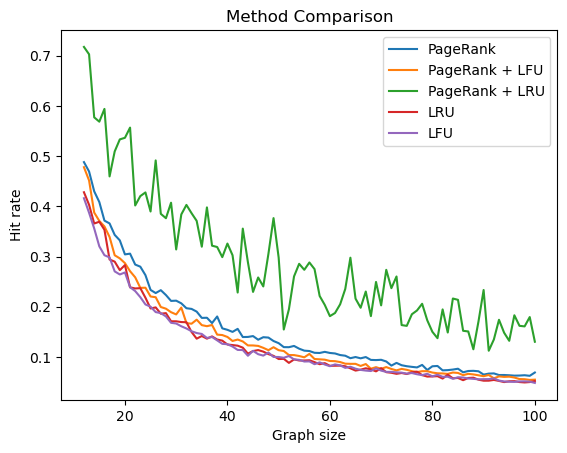

Avg PageRank Hit Rate: 0.15187297992629634
Avg PageRank + LFU Hit Rate: 0.13660838921043886
Avg PageRank + LRU Hit Rate: 0.28732152738544775
Avg LFU Hit Rate: 0.12173401446232632
Avg LRU Hit Rate: 0.12447162739852101


In [323]:
from matplotlib import pyplot as plt
import numpy as np

plt.plot(range(MIN_NODES, MAX_NODES+1), [page_rank_hit_rate[i] for i in range(MIN_NODES, MAX_NODES+1)], label='PageRank')
plt.plot(range(MIN_NODES, MAX_NODES+1), [page_rank_lfu_hit_rate[i] for i in range(MIN_NODES, MAX_NODES+1)], label='PageRank + LFU')
plt.plot(range(MIN_NODES, MAX_NODES+1), [page_rank_lru_hit_rate[i] for i in range(MIN_NODES, MAX_NODES+1)], label='PageRank + LRU')
plt.plot(range(MIN_NODES, MAX_NODES+1), [lru_hit_rate[i] for i in range(MIN_NODES, MAX_NODES+1)], label='LRU')
plt.plot(range(MIN_NODES, MAX_NODES+1), [lfu_hit_rate[i] for i in range(MIN_NODES, MAX_NODES+1)], label='LFU')
plt.xlabel('Graph size')
plt.ylabel('Hit rate')
plt.title('Method Comparison')
plt.legend()
plt.show()
print("Avg PageRank Hit Rate:", np.mean(list(page_rank_hit_rate.values())))
print("Avg PageRank + LFU Hit Rate:", np.mean(list(page_rank_lfu_hit_rate.values())))
print("Avg PageRank + LRU Hit Rate:", np.mean(list(page_rank_lru_hit_rate.values())))
print("Avg LFU Hit Rate:", np.mean(list(lfu_hit_rate.values())))
print("Avg LRU Hit Rate:", np.mean(list(lru_hit_rate.values())))